# Практическая работа №8
# "Баттл моделей"



> @Гришина Ксения, 23.Б16-мм

> @Гусева Варвара, 23.Б16-мм

> @Якубовская Ангелина, 23.Б16-мм


# Подготовка данных:

##  Датасет 1

### ∀ Импорты

In [1]:
import os
from google.colab import drive

import pandas as pd
import numpy as np

from xgboost import XGBRegressor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

## Датасет

Считаем скачанный датасет

In [2]:
# через mount. Это удобнее, так делаю в работе №2 и далее
# Соединяем Google Drive к Collab
gdrive_dir = '/content/drive/'
drive.mount(gdrive_dir, force_remount = True)

# Считываем датасет
data = pd.read_excel('/content/drive/MyDrive/ML-SPbU-HW/HW_8/dataset_1_battle_without_predict.xlsx', header=None)

Mounted at /content/drive/


Проверим корректность считывания файла и попробуем посмотреть первые записи.

In [3]:
data.head()

,0
0,"Date,Day,Temp_max,Temp_avg,Temp_min,Dew_max,De..."
1,"2016-01-06,1,85,74.8,68,74,71.4,66,100,89.4,65..."
2,"2016-02-06,2,76,71.2,66,74,70.3,66,100,96.8,89..."
3,"2016-03-06,3,79,72.1,68,72,70.0,68,100,93.6,72..."
4,"2016-04-06,4,76,71.2,69,73,70.0,66,100,96.1,85..."


разобьем на колонки

In [4]:
data = data[0].str.split(",", expand=True)

In [5]:
data.columns = [
    "Date","Day","Temp_max","Temp_avg","Temp_min",
    "Dew_max","Dew_avg","Dew_min","Hum_max","Hum_avg","Hum_min",
    "Wind_max","Wind_avg","Wind_min","Press_max","Press_avg",
    "Press_min","Precipit","day_of_week"
]

In [6]:
data = data.drop(0)

Посмотрим на структуру

In [7]:
data

,Date,Day,Temp_max,Temp_avg,Temp_min,Dew_max,Dew_avg,Dew_min,Hum_max,Hum_avg,Hum_min,Wind_max,Wind_avg,Wind_min,Press_max,Press_avg,Press_min,Precipit,day_of_week
1,2016-01-06,1,85,74.8,68,74,71.4,66,100,89.4,65,21,9.5,0,29.8,29.8,29.7,0.0,2
2,2016-02-06,2,76,71.2,66,74,70.3,66,100,96.8,89,18,7.8,0,29.8,29.8,29.7,4.33,5
3,2016-03-06,3,79,72.1,68,72,70.0,68,100,93.6,72,18,4.7,0,29.8,29.8,29.7,3.18,6
4,2016-04-06,4,76,71.2,69,73,70.0,66,100,96.1,85,20,7.0,0,29.8,29.7,29.7,2.37,2
5,2016-05-06,5,82,73.8,68,72,70.0,68,100,88.7,62,17,7.7,0,29.7,29.7,29.7,0.39,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1528,2020-06-08,6,94,85.9,77,76,73.8,72,90,68.3,52,16,6.2,0,29.9,29.9,29.8,0.0,0
1529,2020-07-08,7,94,86.0,77,77,74.4,72,94,69.6,52,14,5.7,0,29.9,29.9,29.9,0.0,2
1530,2020-08-08,8,94,85.4,76,77,74.0,70,94,70.6,46,14,5.1,0,30.0,29.9,29.9,0.0,5
1531,2020-09-08,9,96,86.4,77,78,74.7,72,94,69.7,46,18,7.5,0,30.0,30.0,29.9,0.01,1


In [8]:
data

,Date,Day,Temp_max,Temp_avg,Temp_min,Dew_max,Dew_avg,Dew_min,Hum_max,Hum_avg,Hum_min,Wind_max,Wind_avg,Wind_min,Press_max,Press_avg,Press_min,Precipit,day_of_week
1,2016-01-06,1,85,74.8,68,74,71.4,66,100,89.4,65,21,9.5,0,29.8,29.8,29.7,0.0,2
2,2016-02-06,2,76,71.2,66,74,70.3,66,100,96.8,89,18,7.8,0,29.8,29.8,29.7,4.33,5
3,2016-03-06,3,79,72.1,68,72,70.0,68,100,93.6,72,18,4.7,0,29.8,29.8,29.7,3.18,6
4,2016-04-06,4,76,71.2,69,73,70.0,66,100,96.1,85,20,7.0,0,29.8,29.7,29.7,2.37,2
5,2016-05-06,5,82,73.8,68,72,70.0,68,100,88.7,62,17,7.7,0,29.7,29.7,29.7,0.39,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1528,2020-06-08,6,94,85.9,77,76,73.8,72,90,68.3,52,16,6.2,0,29.9,29.9,29.8,0.0,0
1529,2020-07-08,7,94,86.0,77,77,74.4,72,94,69.6,52,14,5.7,0,29.9,29.9,29.9,0.0,2
1530,2020-08-08,8,94,85.4,76,77,74.0,70,94,70.6,46,14,5.1,0,30.0,29.9,29.9,0.0,5
1531,2020-09-08,9,96,86.4,77,78,74.7,72,94,69.7,46,18,7.5,0,30.0,30.0,29.9,0.01,1


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1532 entries, 1 to 1532
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Date         1532 non-null   object
 1   Day          1532 non-null   object
 2   Temp_max     1532 non-null   object
 3   Temp_avg     1532 non-null   object
 4   Temp_min     1532 non-null   object
 5   Dew_max      1532 non-null   object
 6   Dew_avg      1532 non-null   object
 7   Dew_min      1532 non-null   object
 8   Hum_max      1532 non-null   object
 9   Hum_avg      1532 non-null   object
 10  Hum_min      1532 non-null   object
 11  Wind_max     1532 non-null   object
 12  Wind_avg     1532 non-null   object
 13  Wind_min     1532 non-null   object
 14  Press_max    1532 non-null   object
 15  Press_avg    1532 non-null   object
 16  Press_min    1532 non-null   object
 17  Precipit     1532 non-null   object
 18  day_of_week  1532 non-null   object
dtypes: object(19)
memory usage:

Все успешно подгрузилось.
- Заметим, что в данных **нет пропусков**


- Видим, что **есть неправильные типы данных** (многочисленные `object`-ы, `Date` типа `float`)

##  Обработка неправильных типов данных

In [10]:
data['Date'] = pd.to_datetime(data['Date'])

numeric_cols = [
    'Temp_max','Temp_avg','Temp_min',
    'Dew_max','Dew_avg','Dew_min',
    'Hum_max','Hum_avg','Hum_min',
    'Wind_max','Wind_avg','Wind_min',
    'Press_max','Press_avg','Press_min',
    'Precipit','day_of_week'
]

data[numeric_cols] = data[numeric_cols].apply(pd.to_numeric, errors='coerce')

In [11]:
data = data.sort_values('Date')

Строим временные лаги (для модели)

In [12]:
for lag in range(1, 31):
    data[f'lag_{lag}'] = data['Precipit'].shift(lag)

data = data.dropna()

In [13]:
train = data.iloc[:-20]
test = data.iloc[-20:]

# Модель 1 (XGBoost)

In [27]:
X_train = train[[f'lag_{i}' for i in range(1, 31)]]
y_train = train['Precipit']

model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.03,
    max_depth=5,
)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.03, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

In [29]:
last_values = data['Precipit'].values[-30:]  # последние 30 значений
future_preds = []

for _ in range(20):
    X = np.array(last_values[-30:]).reshape(1, -1)
    pred = model.predict(X)[0]
    future_preds.append(pred)
    last_values = np.append(last_values, pred)

In [31]:
future_preds

[np.float32(0.0032099953),
 np.float32(0.11073155),
 np.float32(0.3902607),
 np.float32(0.036759276),
 np.float32(0.031465027),
 np.float32(0.052129902),
 np.float32(0.10101227),
 np.float32(0.05624587),
 np.float32(0.24069771),
 np.float32(0.46001953),
 np.float32(0.18609454),
 np.float32(0.52745694),
 np.float32(-0.007469237),
 np.float32(0.20664594),
 np.float32(0.034232937),
 np.float32(0.11479361),
 np.float32(0.22892049),
 np.float32(0.14812607),
 np.float32(0.40098062),
 np.float32(0.119691856)]

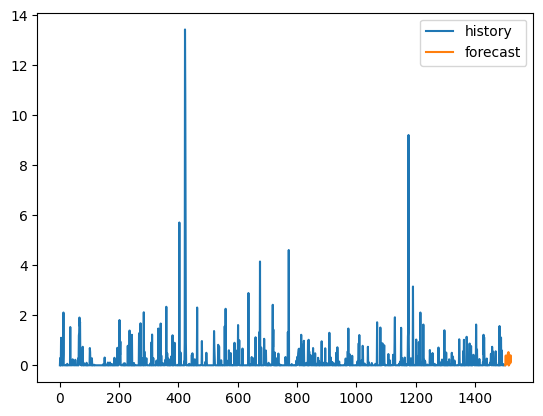

In [33]:
plt.plot(range(len(data)), data['Precipit'], label='history')
plt.plot(range(len(data), len(data)+20), future_preds, label='forecast')
plt.legend()
plt.show()

# Модель 2 (LSTM)

In [15]:
# 1. Подготовка данных
data['Date'] = pd.to_datetime(data['Date'])
data = data.sort_values('Date')

data['Precipit'] = pd.to_numeric(data['Precipit'], errors='coerce')
data = data.dropna(subset=['Precipit'])

data = data['Precipit'].values.reshape(-1, 1)

# Масштабирование
scaler = MinMaxScaler()
scaled = scaler.fit_transform(data)

IndexError: only integers, slices (`:`), ellipsis (`...`), numpy.newaxis (`None`) and integer or boolean arrays are valid indices

In [ ]:
# 2. Создание окон для LSTM
window = 30  # длина окна

X = []
y = []

for i in range(window, len(scaled)):
    X.append(scaled[i-window:i, 0])
    y.append(scaled[i, 0])

X = np.array(X)
y = np.array(y)

# LSTM вход: (samples, timesteps, features)
X = X.reshape((X.shape[0], X.shape[1], 1))

In [ ]:
# 3. LSTM модель
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(window, 1)),
    LSTM(32),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

In [ ]:
# 4. Обучение
history = model.fit(X, y, epochs=30, batch_size=32, verbose=1)

In [ ]:
# 5. Прогноз на 20 шагов вперёд
last_window = scaled[-window:]   # последние 30 значений
future_predictions_scaled = []

current_input = last_window.copy()

for _ in range(20):
    # форма (1, window, 1)
    pred = model.predict(current_input.reshape(1, window, 1))[0, 0]

    future_predictions_scaled.append(pred)

    # добавляем прогноз в окно
    current_input = np.append(current_input[1:], [[pred]], axis=0)

# обратно к реальным значениям
future_predictions = scaler.inverse_transform(
    np.array(future_predictions_scaled).reshape(-1, 1)
).flatten()

print("Прогноз LSTM на 20 будущих значений:")
print(future_predictions)